In [10]:
# ============================================================
# Cell 1: Import Libraries and Set Paths
# Purpose: Prepare Notebook 3 for research analysis
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = "/mnt/g/banglafake-detection"

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

print("Notebook 3 environment ready!")
print("Project root:", PROJECT_ROOT)
print("Figures directory:", FIGURES_DIR)

Notebook 3 environment ready!
Project root: /mnt/g/banglafake-detection
Figures directory: /mnt/g/banglafake-detection/reports/figures


In [2]:
# ============================================================
# Cell 2: Load Processed Datasets
# Purpose: Load train, validation, and test data for analysis
# ============================================================

train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv"))

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nLabel distribution:")
print("Train:\n", train_df["label"].value_counts().sort_index())
print("Validation:\n", val_df["label"].value_counts().sort_index())
print("Test:\n", test_df["label"].value_counts().sort_index())

Train shape: (2790, 3)
Validation shape: (598, 3)
Test shape: (599, 3)

Label distribution:
Train:
 label
0    1393
1    1397
Name: count, dtype: int64
Validation:
 label
0    298
1    300
Name: count, dtype: int64
Test:
 label
0    299
1    300
Name: count, dtype: int64


In [3]:
# ============================================================
# Cell 3: Check Saved Evaluation Artifacts
# Purpose: Verify existing test metrics and prediction outputs
# ============================================================

metrics_path = os.path.join(REPORTS_DIR, "final_test_metrics.csv")
cm_path = os.path.join(REPORTS_DIR, "confusion_matrix.csv")
report_path = os.path.join(REPORTS_DIR, "classification_report.txt")
roc_path = os.path.join(REPORTS_DIR, "roc_curve.csv")

for path in [metrics_path, cm_path, report_path, roc_path]:
    print(f"{os.path.basename(path)}:", "FOUND" if os.path.exists(path) else "MISSING")

final_test_metrics.csv: FOUND
confusion_matrix.csv: FOUND
classification_report.txt: FOUND
roc_curve.csv: FOUND


In [5]:
# ============================================================
# Cell 4: Load Final Test Metrics
# Purpose: Display final model performance correctly
# ============================================================

final_metrics = pd.read_csv(metrics_path)

display(final_metrics)

print("\nFinal Test Performance:")

for metric in final_metrics.columns:
    print(f"{metric}: {final_metrics.loc[0, metric]:.4f}")

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.973289,0.97973,0.966667,0.973154,0.992609



Final Test Performance:
Accuracy: 0.9733
Precision: 0.9797
Recall: 0.9667
F1 Score: 0.9732
ROC-AUC: 0.9926


In [6]:
# ============================================================
# Cell 5: Confusion Matrix Analysis
# Purpose: Analyze Fake/Real classification errors
# ============================================================

confusion_matrix_df = pd.read_csv(cm_path, index_col=0)

display(confusion_matrix_df)

print("\nConfusion Matrix:")
print(confusion_matrix_df)

print("\nTotal Errors:",
      confusion_matrix_df.values.sum() -
      np.trace(confusion_matrix_df.values))

,Predicted_Fake,Predicted_Real
Actual_Fake,293,6
Actual_Real,10,290



Confusion Matrix:
             Predicted_Fake  Predicted_Real
Actual_Fake             293               6
Actual_Real              10             290

Total Errors: 16


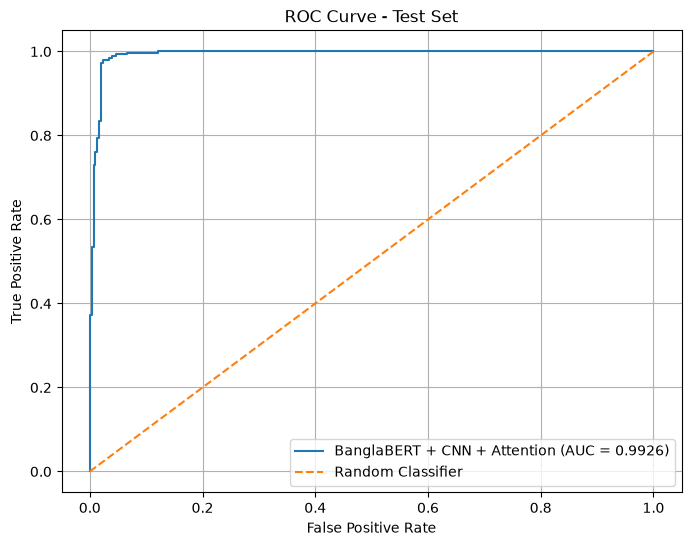

Verified ROC-AUC: 0.9926
ROC figure saved successfully!


In [7]:
# ============================================================
# Cell 6: ROC-AUC Analysis
# Purpose: Verify ROC-AUC and generate the final ROC figure
# ============================================================

roc_df = pd.read_csv(roc_path)

fpr = roc_df["False Positive Rate"].values
tpr = roc_df["True Positive Rate"].values

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"BanglaBERT + CNN + Attention (AUC = {final_metrics.loc[0, 'ROC-AUC']:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(FIGURES_DIR, "roc_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Verified ROC-AUC: {final_metrics.loc[0, 'ROC-AUC']:.4f}")
print("ROC figure saved successfully!")

In [8]:
# ============================================================
# Cell 7: Classification Report Analysis
# Purpose: Load and display class-wise test performance
# ============================================================

with open(report_path, "r", encoding="utf-8") as f:
    classification_report_text = f.read()

print(classification_report_text)

BanglaBERT + CNN + Attention
Final Test Classification Report

              precision    recall  f1-score   support

        Fake     0.9670    0.9799    0.9734       299
        Real     0.9797    0.9667    0.9732       300

    accuracy                         0.9733       599
   macro avg     0.9734    0.9733    0.9733       599
weighted avg     0.9734    0.9733    0.9733       599



In [11]:
# ============================================================
# Cell 8: Add Category Metadata to Test Set
# Purpose: Restore category information for research analysis
# ============================================================

real_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw",
    "Bangla_Real_News_Dataset.csv"
)

fake_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw",
    "Bangla_Fake_News_Dataset.csv"
)

real_raw = pd.read_csv(real_path)
fake_raw = pd.read_csv(fake_path)

raw_df = pd.concat(
    [real_raw, fake_raw],
    ignore_index=True
)

def clean_text_for_analysis(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

raw_df["text"] = (
    raw_df["Headline"].apply(clean_text_for_analysis)
    + " "
    + raw_df["Content"].apply(clean_text_for_analysis)
).str.strip()

category_map = (
    raw_df[["text", "Category"]]
    .drop_duplicates(subset=["text"])
)

test_analysis_df = test_df.merge(
    category_map,
    on="text",
    how="left"
)

print("Test rows:", len(test_analysis_df))
print("Missing categories:", test_analysis_df["Category"].isna().sum())

print("\nCategory distribution:")
display(
    test_analysis_df["Category"]
    .value_counts()
    .sort_index()
)

Test rows: 599
Missing categories: 0

Category distribution:


Category
Crime               35
Crime               11
Editorial           21
Education           31
Entertainment       25
Entertainment        7
Finance             22
International       88
Lifestyle           32
Miscellaneous       67
Miscellaneous\t     23
Miscellaneous        1
National            52
Politics           111
Sports              46
Sports               1
Technology          26
Name: count, dtype: int64